C:\Users\zyl\AppData\Local\Temp\ipykernel_31060\1707480249.py:115: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zyl\AppData\Local\Temp\ipykernel_31060\1707480249.py:115: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zyl\AppData\Local\Temp\ipykernel_31060\1707480249.py:115: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zyl\AppData\Local\Temp\ipykernel_31060\1707480249.py:115: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zyl\AppData\Local\Temp\ipykernel_31060\1707480249.py:115: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zyl\AppData\Local\Temp\ipykernel_31060\1707480249.py:115: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missi

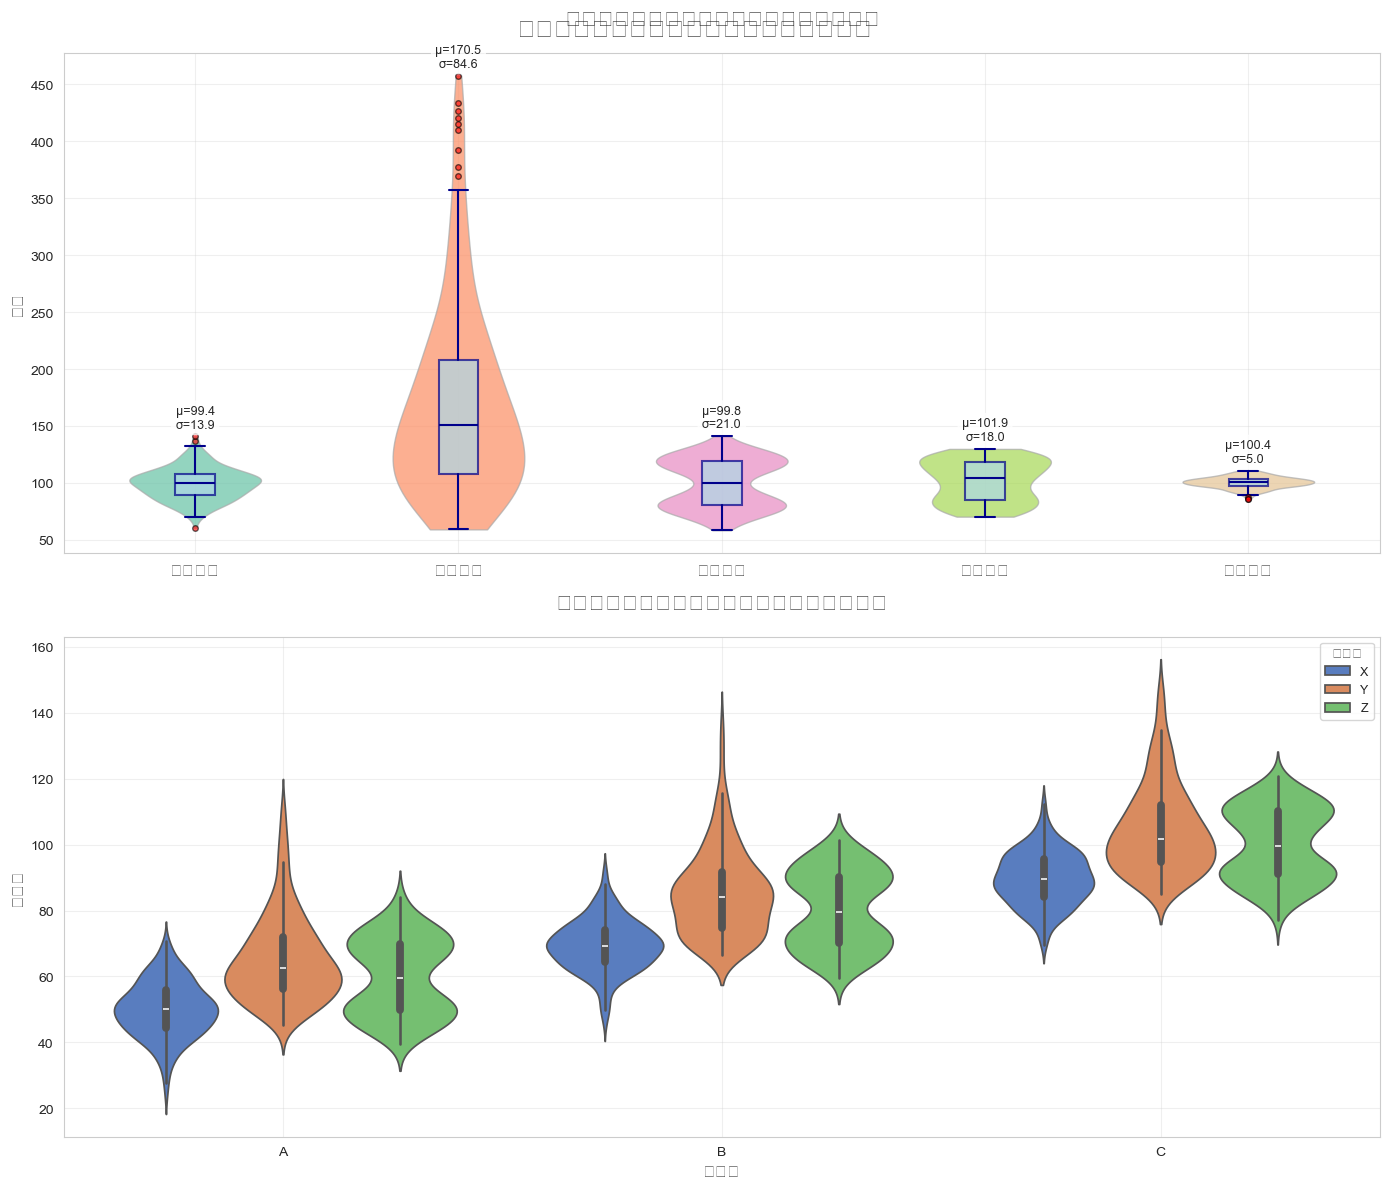

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# 创建示例数据
np.random.seed(42)
n = 200

# 生成不同类型分布的数据
data_dict = {
    '正态分布': np.random.normal(100, 15, n),
    '偏态分布': np.random.gamma(2, 2, n) * 30 + 50,
    '双峰分布': np.concatenate([np.random.normal(80, 8, n//2), np.random.normal(120, 8, n//2)]),
    '均匀分布': np.random.uniform(70, 130, n),
    '尖峰分布': np.random.normal(100, 5, n)  # 较小的标准差形成尖峰
}

# 转换为长格式DataFrame
df_list = []
for dist_name, values in data_dict.items():
    for value in values:
        df_list.append([dist_name, value])
df = pd.DataFrame(df_list, columns=['分布类型', '数值'])

# 创建图形和子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 子图1：小提琴图 + 箱线图
violin_parts = ax1.violinplot([data_dict[key] for key in data_dict.keys()], 
                             showmeans=False, showmedians=False, showextrema=False)

# 为小提琴图着色
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(plt.cm.Set2(i/len(data_dict)))
    pc.set_alpha(0.7)
    pc.set_edgecolor('darkgray')
    pc.set_linewidth(1)

# 添加箱线图到小提琴图上
box_plot = ax1.boxplot([data_dict[key] for key in data_dict.keys()], 
                       positions=np.arange(1, len(data_dict)+1),
                       widths=0.15, patch_artist=True,
                       showfliers=True, flierprops=dict(marker='o', markerfacecolor='red', 
                                                       markersize=4, alpha=0.6))

# 美化箱线图
for element in ['boxes', 'whiskers', 'caps', 'medians']:
    for line in box_plot[element]:
        line.set_color('darkblue')
        line.set_linewidth(1.5)

for patch in box_plot['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

# 设置子图1的标题和标签
ax1.set_title('小提琴箱线图：不同分布类型的数据可视化', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(np.arange(1, len(data_dict)+1))
ax1.set_xticklabels(data_dict.keys(), fontsize=12)
ax1.set_ylabel('数值', fontsize=12)
ax1.grid(True, alpha=0.3)

# 添加均值和标准差标注
for i, (dist_name, values) in enumerate(data_dict.items()):
    mean = np.mean(values)
    std = np.std(values)
    ax1.text(i+1, np.max(values)+5, f'μ={mean:.1f}\nσ={std:.1f}', 
             ha='center', va='bottom', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", 
                                                           facecolor="white", alpha=0.7))

# 子图2：分组小提琴箱线图（更复杂的数据）
np.random.seed(123)
categories = ['A', 'B', 'C']
subcategories = ['X', 'Y', 'Z']

# 创建分组数据
group_data = []
for cat in categories:
    for subcat in subcategories:
        # 为每个组合创建不同分布的数据
        base_value = 50 + (ord(cat) - 65) * 20 + (ord(subcat) - 88) * 5
        if subcat == 'X':
            values = np.random.normal(base_value, 8, n)
        elif subcat == 'Y':
            values = np.random.gamma(2, 2, n) * 5 + base_value - 10
        else:  # Z
            values = np.concatenate([np.random.normal(base_value-10, 5, n//2), 
                                   np.random.normal(base_value+10, 5, n//2)])
        
        for val in values:
            group_data.append([cat, subcat, val])

df_group = pd.DataFrame(group_data, columns=['类别', '子类别', '数值'])

# 使用seaborn绘制分组小提琴图
sns.violinplot(x='类别', y='数值', hue='子类别', data=df_group, 
               palette='muted', inner='box', ax=ax2, dodge=True)

# 美化第二个子图
ax2.set_title('分组小提琴箱线图：类别与子类别的数据分布', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('主类别', fontsize=12)
ax2.set_ylabel('测量值', fontsize=12)
ax2.legend(title='子类别', title_fontsize=10, fontsize=9)
ax2.grid(True, alpha=0.3)

# 调整布局
plt.tight_layout()

# 添加整体标题
fig.suptitle('数据分布可视化：小提琴图与箱线图的结合', 
             fontsize=18, fontweight='bold', y=0.98)

plt.show()